In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

df = pd.read_csv("auto-mpg.csv")   # rename file to match your download

print("First 5 rows:")
display(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [2]:
# ---------------------------------------------------------------
# 2. Basic Data Cleaning
# ---------------------------------------------------------------

# Replace '?' with NaN (some versions of dataset may include '?')
df.replace("?", np.nan, inplace=True)

# Convert horsepower to numeric (some datasets store it as string)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Drop rows with missing MPG
df = df.dropna(subset=["mpg"])

# Replace remaining missing numeric values with median
for col in ["horsepower"]:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values after cleaning:")
print(df.isnull().sum())


Remaining missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


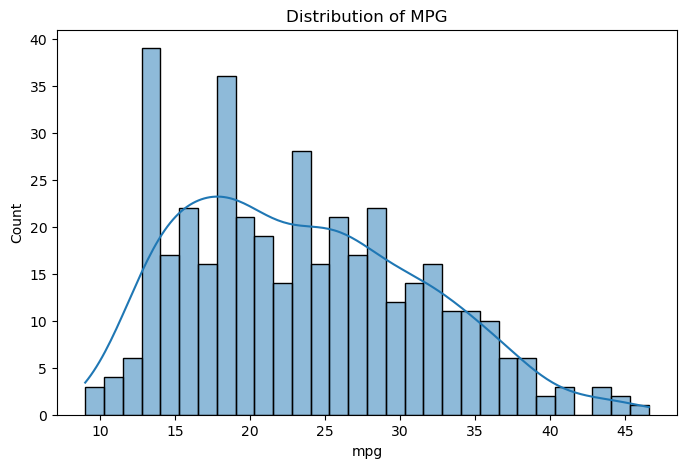

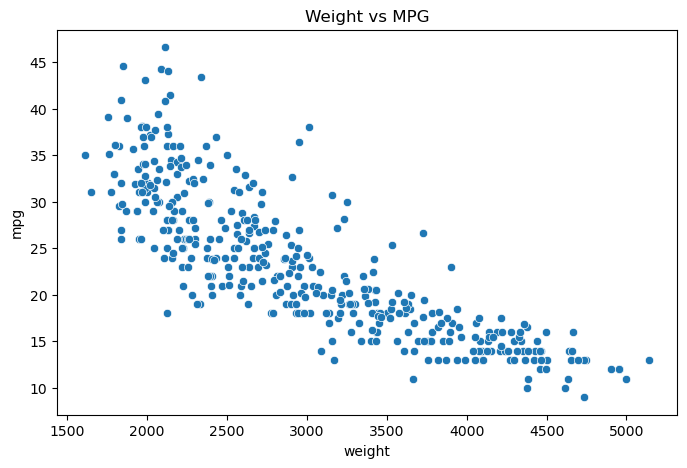

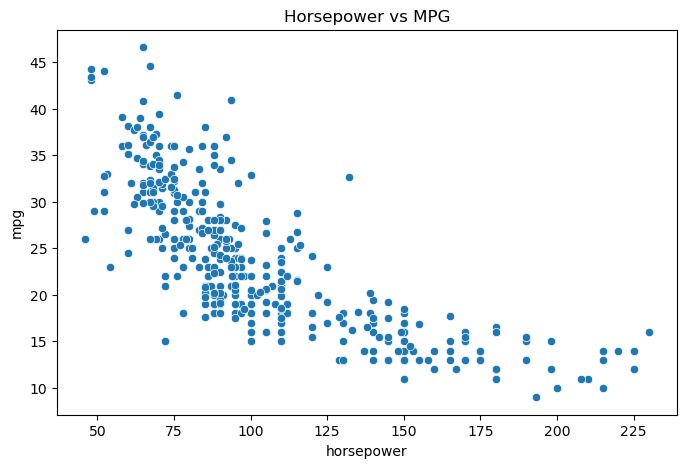

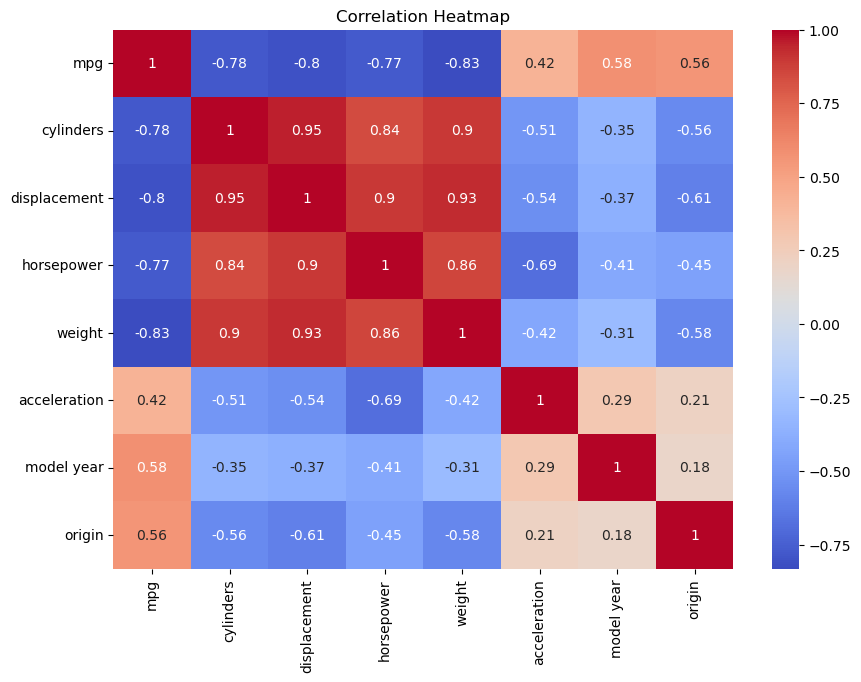

In [12]:
# ---------------------------------------------------------------
# 3. Visualizations
# ---------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], kde=True, bins=30)
plt.title("Distribution of MPG")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="weight", y="mpg")
plt.title("Weight vs MPG")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="horsepower", y="mpg")
plt.title("Horsepower vs MPG")
plt.show()

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# ---------------------------------------------------------------
# 4. Preprocessing
# ---------------------------------------------------------------

X = df.drop(columns=["mpg"])
y = df["mpg"]

numeric_features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"]
categorical_features = ["origin"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

X_processed = preprocess.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print("Processed feature shape:", X_processed.shape)


Processed feature shape: (398, 9)


In [5]:
# ---------------------------------------------------------------
# 5. OLS Regression (Closed Form)
# ---------------------------------------------------------------

# Convert to numpy arrays
X_train_ols = np.array(X_train)
y_train_ols = np.array(y_train).reshape(-1, 1)
X_test_ols = np.array(X_test)
y_test_ols = np.array(y_test).reshape(-1, 1)

# Add bias term (column of 1's)
X_train_bias = np.hstack([np.ones((X_train_ols.shape[0], 1)), X_train_ols])
X_test_bias = np.hstack([np.ones((X_test_ols.shape[0], 1)), X_test_ols])

# Closed form solution
w_ols = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train_ols

# Predictions
y_pred_train_ols = X_train_bias @ w_ols
y_pred_test_ols = X_test_bias @ w_ols

# Evaluation
rmse_train_ols = np.sqrt(mean_squared_error(y_train_ols, y_pred_train_ols))
rmse_test_ols = np.sqrt(mean_squared_error(y_test_ols, y_pred_test_ols))

print("OLS Train RMSE:", rmse_train_ols)
print("OLS Test RMSE:", rmse_test_ols)


OLS Train RMSE: 22.993952599825466
OLS Test RMSE: 20.646358736585224


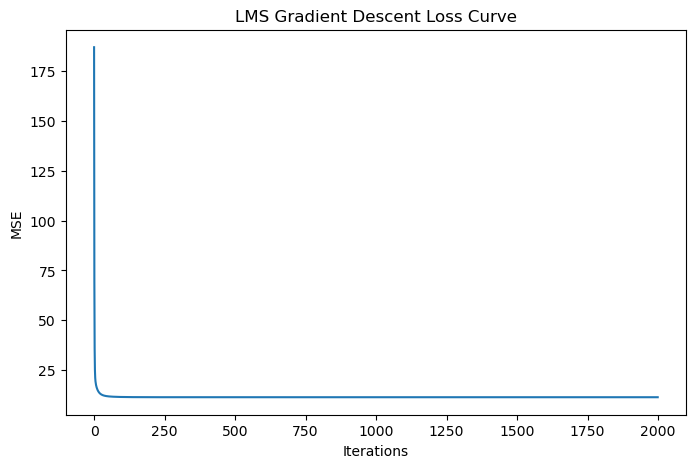

LMS Train RMSE: 3.3697470917159182
LMS Test RMSE: 2.887673368091784


In [6]:
# ---------------------------------------------------------------
# 6. LMS Gradient Descent Regression
# ---------------------------------------------------------------

# Reuse bias-added matrices
X = X_train_bias
y = y_train_ols

# Hyperparameters
eta = 0.001
iterations = 2000

# Initialize weights
w = np.zeros((X.shape[1], 1))

loss_history = []

for i in range(iterations):
    gradient = X.T @ (X @ w - y)
    w = w - eta * gradient
    mse = mean_squared_error(y, X @ w)
    loss_history.append(mse)

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("LMS Gradient Descent Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

# Predictions
y_pred_train_lms = X_train_bias @ w
y_pred_test_lms = X_test_bias @ w

# Evaluation
rmse_train_lms = np.sqrt(mean_squared_error(y_train_ols, y_pred_train_lms))
rmse_test_lms = np.sqrt(mean_squared_error(y_test_ols, y_pred_test_lms))

print("LMS Train RMSE:", rmse_train_lms)
print("LMS Test RMSE:", rmse_test_lms)


In [8]:
# ---------------------------------------------------------------
# 7. Final Comparison Table
# ---------------------------------------------------------------

results = pd.DataFrame({
    "Model": ["OLS", "LMS"],
    "Train RMSE": [rmse_train_ols, rmse_train_lms],
    "Test RMSE": [rmse_test_ols, rmse_test_lms]
})

display(results)

,Model,Train RMSE,Test RMSE
0,OLS,22.993953,20.646359
1,LMS,3.369747,2.887673


In [9]:
# ---------------------------------------------------------------
# 8. Save Results & Figures (Optional)
# ---------------------------------------------------------------

results.to_csv("model_results.csv", index=False)

print("Notebook finished successfully.")


Notebook finished successfully.
